# Reconstruct prices & measure cross-DEX gaps

Load the raw extracts, turn the irregular swap events into one aligned, gap-free price series per pool, then compare pools across DEXes.

Pipeline (each step is one `arblib.preprocessing` function):
1. **clean** — keep the last swap (end-of-block price) per pool & block
2. **split** — one series per pool address
3. **gap filter** — drop pools that trade too rarely to reconstruct
4. **reconstruct** — dense block grid, forward-filled prices, shared times
5. **study-start filter** — drop the warm-up margin
6. **analysis / plots** — cross-DEX pairwise price differences

In [1]:
%load_ext autoreload
%autoreload 2

from arblib import data_io, preprocessing as pp, analysis, plotting
from pathlib import Path

## Parameters

- **STUDY_START_TIME** — start of the study window. Must be *after* the collection start (`extract_arbitrage.ipynb`) so prices are already forward-filled for every pool when the study begins.
- **MAX_GAP_BLOCKS** — drop a pool if its largest gap between swaps exceeds this many blocks.

In [2]:

CHAIN = "ethereum"


current = Path.cwd()
while current.name != 'defi_arbitrage' and current != current.parent:
    current = current.parent
BASE_DIR = current if current.name == 'defi_arbitrage' else Path.cwd()

DATA_DIR = BASE_DIR / f"{CHAIN}"

STUDY_START_TIME = "2025-12-31 15:15:00"
MAX_GAP_BLOCKS = 6000

## 0. Load the raw extracts

In [3]:
dfs = data_io.load_pool_csvs(DATA_DIR / "swaps")

Loaded: df_uniswap_swap.csv
          dex  evt_block_number               evt_block_time  evt_index  \
0  uniswap_v3          24133363  2025-12-31 15:00:11.000 UTC         17   
1  uniswap_v4          24133364  2025-12-31 15:00:23.000 UTC          3   
2  uniswap_v3          24133365  2025-12-31 15:00:35.000 UTC         40   
3  uniswap_v4          24133365  2025-12-31 15:00:35.000 UTC        719   
4  uniswap_v3          24133365  2025-12-31 15:00:35.000 UTC        172   

                                         evt_tx_hash      fee  \
0  0x045ccf214364711f41a1e4ebdc460703fb1d3f6ccfae...      100   
1  0x7e40441f67a6ffeb29115fdf3028481faf2a2b9772bf...  8388608   
2  0xa0671b25449576f08044498e74206b1b004d9860f4cb...      100   
3  0xec65bce6ee919efd00169fab04f7787eaae97aa3fc5c...  8388608   
4  0x5c069af2566ae61492dfac242196d2726e56a6f049ba...      500   

             liquidity    mid_price  \
0   153272272177511901  2989.985998   
1   100642390586209628  2990.191408   
2   153272272

## 1. Clean — keep the end-of-block price per pool & block

In [4]:
filtered_dfs = pp.clean_all(dfs)

Processed df_uniswap: 1066 rows -> 605 rows
Processed df_pancake: 240 rows -> 180 rows


## 2. Split each DEX into one series per pool

In [5]:
pool_dfs = pp.split_by_pool(filtered_dfs)

Created uniswap_1: 75 rows
Created uniswap_2: 128 rows
Created uniswap_3: 24 rows
Created uniswap_4: 3 rows
Created uniswap_5: 230 rows
Created uniswap_6: 145 rows
Created pancake_1: 137 rows
Created pancake_2: 43 rows

Total: 8 dataframes
['uniswap_1', 'uniswap_2', 'uniswap_3', 'uniswap_4', 'uniswap_5', 'uniswap_6', 'pancake_1', 'pancake_2']


## 3. Drop pools that trade too rarely

In [6]:
pool_dfs, dropped_pools = pp.filter_pools_by_swap_gap(pool_dfs, MAX_GAP_BLOCKS)

k = 6000 blocks
Kept 8 pools

Kept pools:
  uniswap_1: 75 swaps, max consecutive gap = 16 blocks
  uniswap_2: 128 swaps, max consecutive gap = 11 blocks
  uniswap_3: 24 swaps, max consecutive gap = 49 blocks
  uniswap_4: 3 swaps, max consecutive gap = 107 blocks
  uniswap_5: 230 swaps, max consecutive gap = 5 blocks
  uniswap_6: 145 swaps, max consecutive gap = 9 blocks
  pancake_1: 137 swaps, max consecutive gap = 9 blocks
  pancake_2: 43 swaps, max consecutive gap = 24 blocks


## 4. Reconstruct a dense, forward-filled series per pool

In [7]:
reconstructed_pools, global_min, global_max, block_time_map = (
    pp.reconstruct_pool_timeseries(pool_dfs)
)

Global block range: 24133363 to 24133662
Total blocks: 300

uniswap_1: 75 trades -> 295 blocks (98.3%)
uniswap_2: 128 trades -> 298 blocks (99.3%)
uniswap_3: 24 trades -> 297 blocks (99.0%)
uniswap_4: 3 trades -> 235 blocks (78.3%)
uniswap_5: 230 trades -> 300 blocks (100.0%)
uniswap_6: 145 trades -> 299 blocks (99.7%)
pancake_1: 137 trades -> 298 blocks (99.3%)
pancake_2: 43 trades -> 290 blocks (96.7%)

Created 8 reconstructed time series


## 4b. Reconstruct active liquidity per block

Rebuild each pool's `liquidity` column into the running **active-liquidity state** `L`:

- anchor `L` on every swap (its `liquidity` field is ground truth);
- between swaps, add a mint/burn `liquidity_delta` (from `<chain>/liquidity/`) only when it is in range — `tick_lower ≤ current_tick < tick_upper` — applied in `evt_index` order;
- hold `L` constant across blocks with no update (forward-fill).

Pools that appear only in the liquidity files (not in `reconstructed_pools`) are ignored.

In [8]:
from arblib.config import LIQUIDITY_FILES

liq_dfs = data_io.load_pool_csvs(DATA_DIR / "liquidity", files=LIQUIDITY_FILES)

reconstructed_pools = pp.reconstruct_liquidity_states(reconstructed_pools, liq_dfs)

Loaded: df_uniswap_liq.csv
          dex  evt_block_number               evt_block_time  evt_index  \
0  uniswap_v3          24133406  2025-12-31 15:08:47.000 UTC        179   
1  uniswap_v3          24133460  2025-12-31 15:19:35.000 UTC        318   
2  uniswap_v3          24133591  2025-12-31 15:45:47.000 UTC        141   
3  uniswap_v3          24133648  2025-12-31 15:57:11.000 UTC        689   
4  uniswap_v3          24133626  2025-12-31 15:52:47.000 UTC        198   

        liquidity_delta                                        pool  \
0      5244061520071531  0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640   
1  28535564165621841753  0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640   
2       -49393047801584  0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640   
3       148594289172011  0x88e6a0c2ddd26feeb64f039a2c41296fcb3f5640   
4      -509787476461393  0x8ad599c3a0ff1de082011efddc58f1908eb6e6d8   

   tick_lower  tick_upper  
0      196250      196730  
1      196360      196380  
2      1913

## 5. Trim to the study window

In [9]:
filtered_pools = pp.filter_by_start_time(reconstructed_pools, STUDY_START_TIME)

uniswap_1: 300 -> 225 rows
uniswap_2: 300 -> 225 rows
uniswap_3: 300 -> 225 rows
uniswap_4: 300 -> 225 rows
uniswap_5: 300 -> 225 rows
uniswap_6: 300 -> 225 rows
pancake_1: 300 -> 225 rows
pancake_2: 300 -> 225 rows

Filtered all pools by time >= 2025-12-31 15:15:00


## Plot — all Uniswap pools

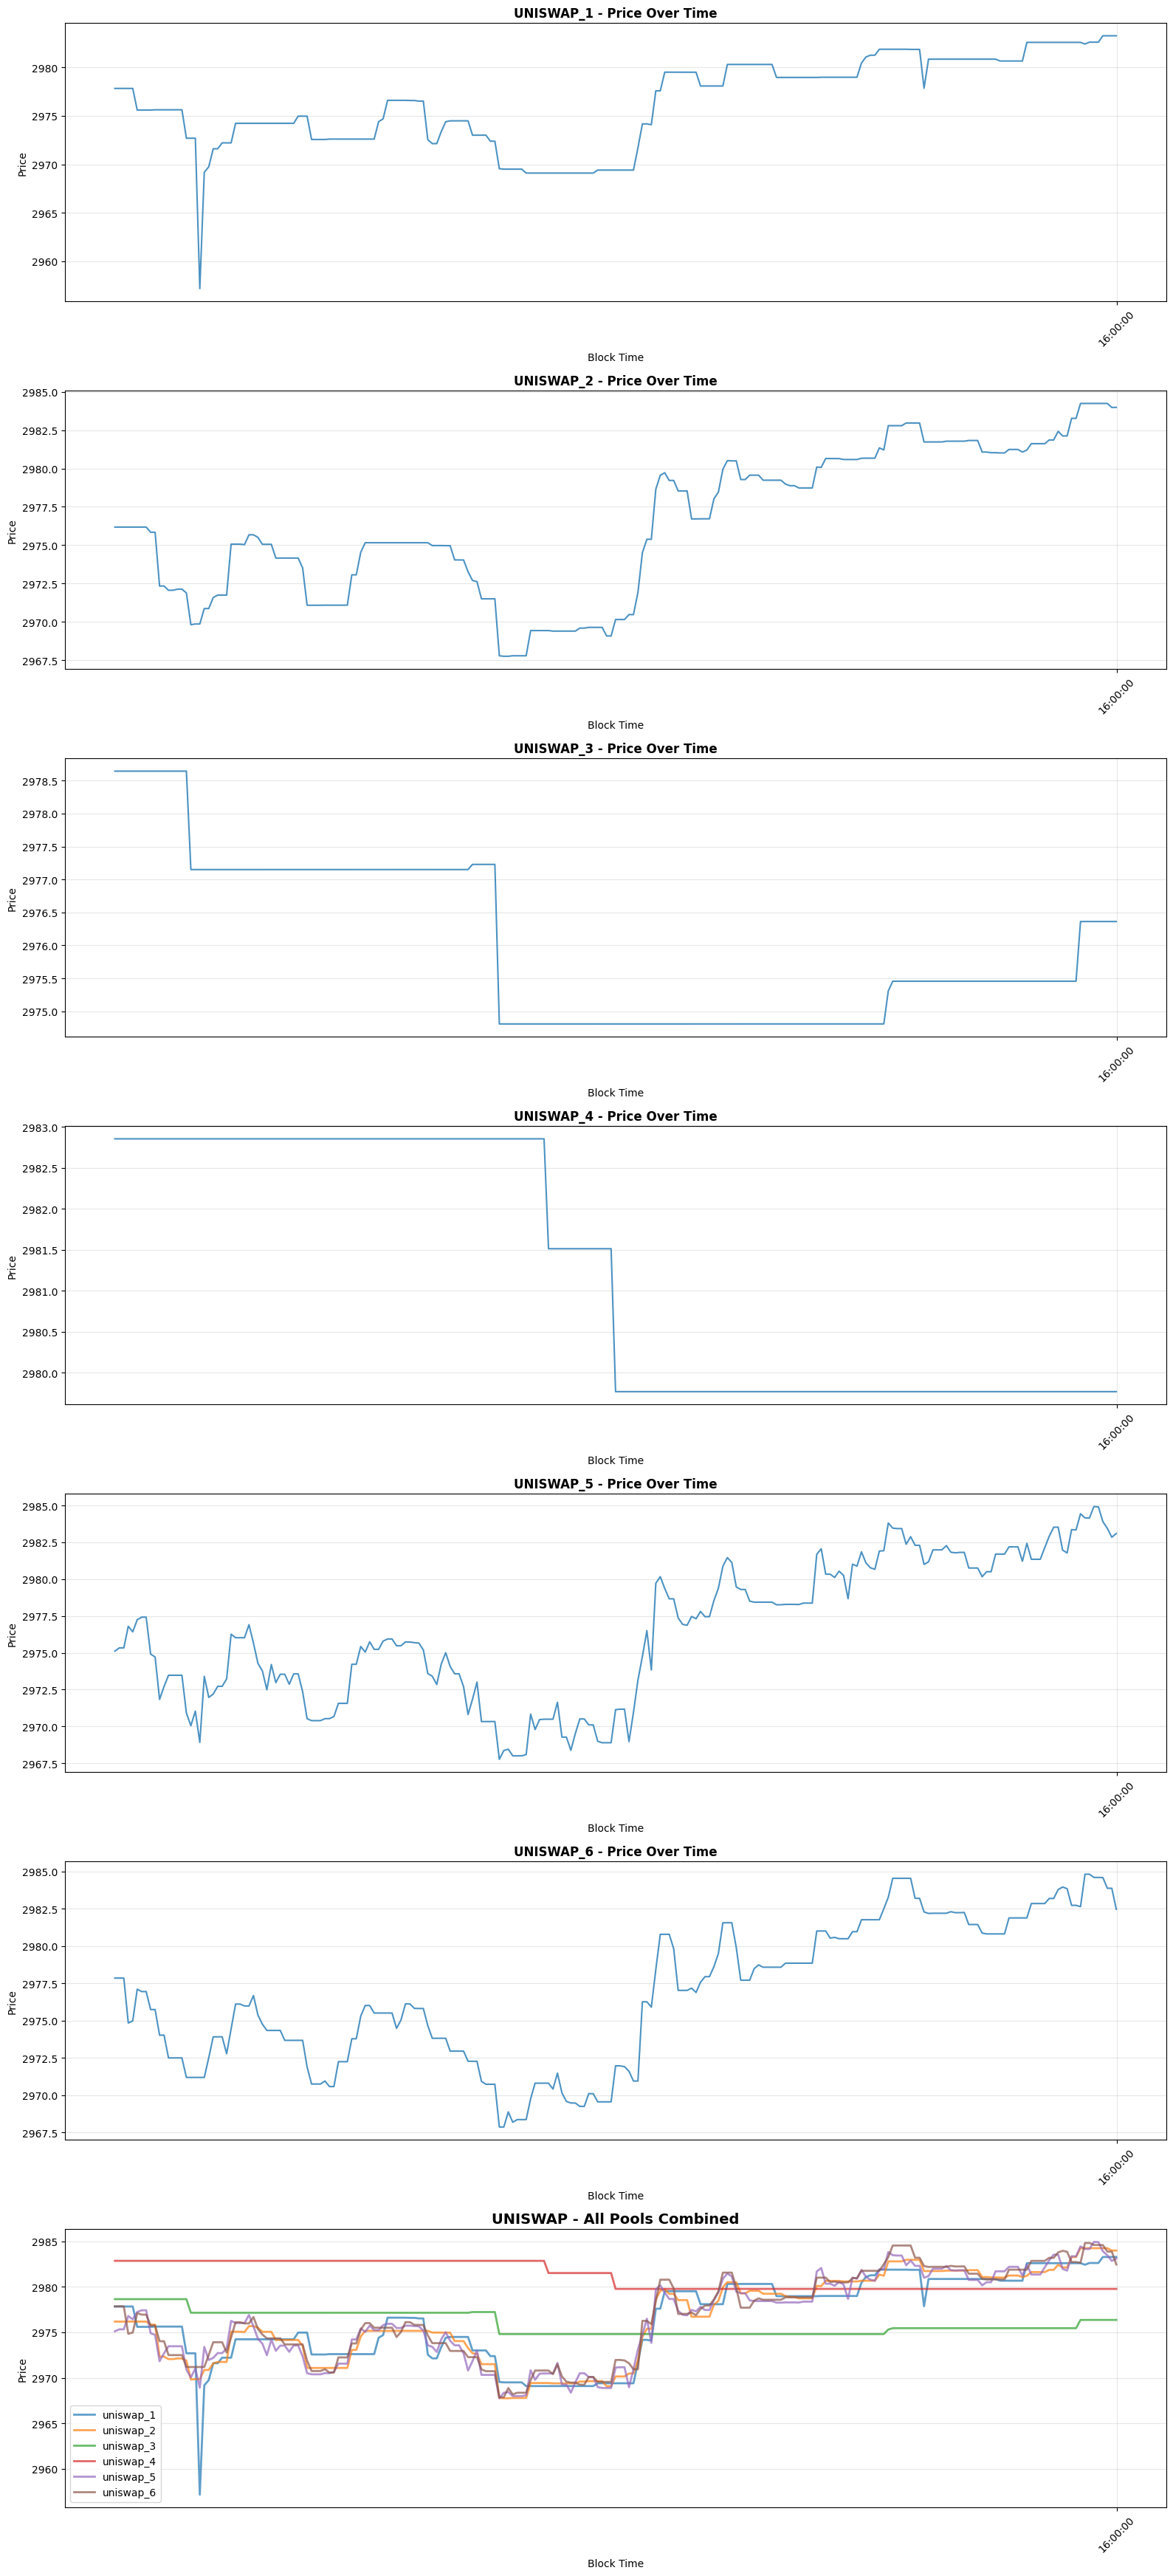


Plotted 6 uniswap pools + 1 combined view
  uniswap_1: 225 blocks
  uniswap_2: 225 blocks
  uniswap_3: 225 blocks
  uniswap_4: 225 blocks
  uniswap_5: 225 blocks
  uniswap_6: 225 blocks


In [10]:
plotting.plot_dex_pools(filtered_pools, dex="uniswap")

## 6. Cross-DEX pairwise price differences

In [11]:
price_differences, all_price_differences = analysis.compute_pairwise_differences(filtered_pools)

DEXes found: ['uniswap', 'pancake']
Pools per DEX: [('uniswap', 6), ('pancake', 2)]

Computed 12 pairwise comparisons:

uniswap_1_vs_pancake_1:
  Rows: 225
  Max diff: 12.931532
  Mean diff: 1.391070
  Min diff: 0.019574

uniswap_1_vs_pancake_2:
  Rows: 225
  Max diff: 12.718176
  Mean diff: 1.015642
  Min diff: 0.010093

uniswap_2_vs_pancake_1:
  Rows: 225
  Max diff: 2.730908
  Mean diff: 0.836662
  Min diff: 0.010508

uniswap_2_vs_pancake_2:
  Rows: 225
  Max diff: 2.434724
  Mean diff: 0.555870
  Min diff: 0.000000

uniswap_3_vs_pancake_1:
  Rows: 225
  Max diff: 8.747698
  Mean diff: 4.804879
  Min diff: 0.385545

uniswap_3_vs_pancake_2:
  Rows: 225
  Max diff: 7.560673
  Mean diff: 4.859384
  Min diff: 0.295219

uniswap_4_vs_pancake_1:
  Rows: 225
  Max diff: 16.792415
  Mean diff: 6.217794
  Min diff: 0.091231

uniswap_4_vs_pancake_2:
  Rows: 225
  Max diff: 15.605390
  Mean diff: 6.046429
  Min diff: 0.186214

uniswap_5_vs_pancake_1:
  Rows: 225
  Max diff: 4.224619
  Mean diff

## Plot — price series for every cross-DEX pair

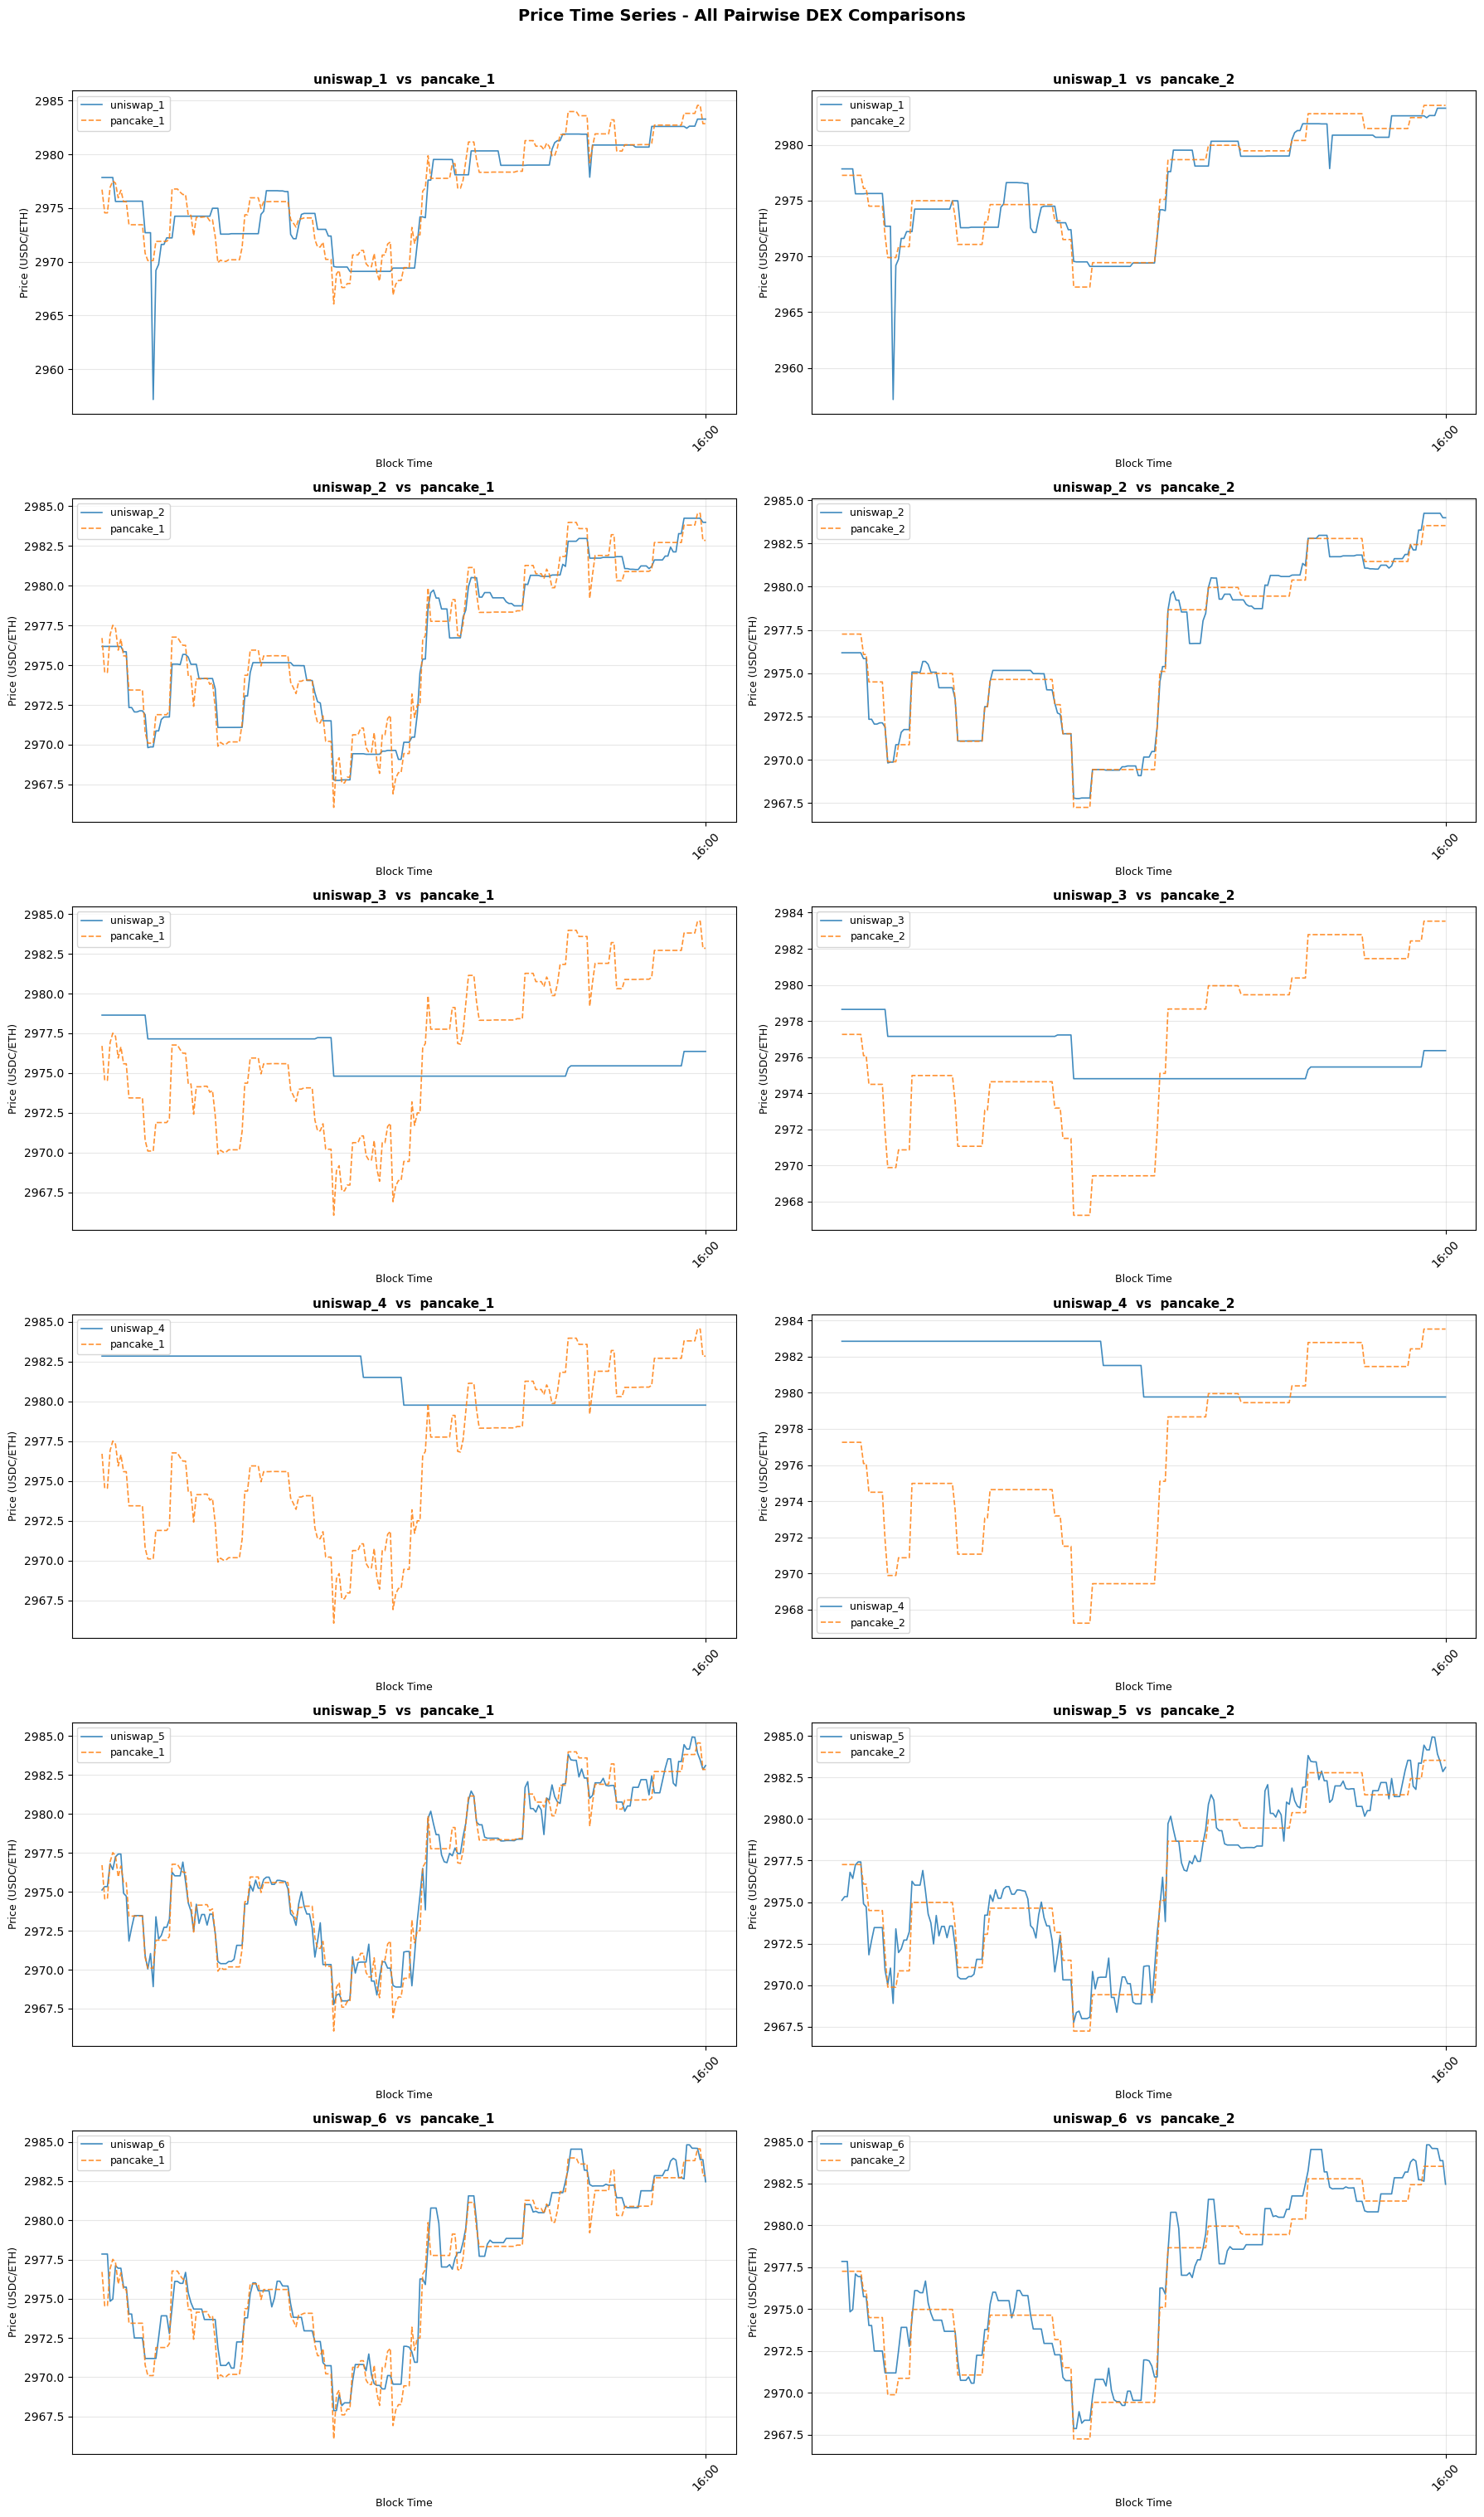

In [12]:
plotting.plot_pairwise_prices(price_differences)

In [13]:
save_dir = DATA_DIR / "processed"

data_io.save_processed_pools(filtered_pools, save_dir)

Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_1.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_2.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_3.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_4.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_5.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/uniswap_6.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/pancake_1.csv
Saved: /Users/matthieu/Downloads/DeFi_limits-to-arbitrage/ethereum/processed/pancake_2.csv
Done.
